# PHẦN 1: TẢI DỮ LIỆU & KỸ THUẬT ĐẶC TRƯNG (FEATURE ENGINEERING)
Trong phần này, hệ thống tiến hành tải dữ liệu từ Kaggle và xây dựng bộ Siêu đặc trưng (Feature Engineering). Thay vì chỉ dùng các biến thời gian thô, mô hình được thiết kế để bắt các tín hiệu kinh doanh cốt lõi:
*   **Chu kỳ nhận lương & Ngày nghỉ:** Nhận diện các ngày `is_payday_window` và `is_weekend` vì đây là thời điểm sức mua có độ đàn hồi cao nhất.
*   **Sự kiện vĩ mô:** Đánh dấu các ngày Mega Sale (11/11, 12/12) và Micro-holidays (14/02, 08/03).
*   **Tương tác chéo (Synergy Effect):** Kết hợp tỷ lệ chiết khấu sâu (max_discount_pct) với sự kiện (Payday/Mega Sale) để tạo ra các biến tương tác chéo nhằm đo lường hiệu ứng đòn bẩy kích cầu.

In [13]:
# Cài đặt thư viện cần thiết
!pip install -q catboost kagglehub shap

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap
import kagglehub
from google.colab import userdata

# 1. CỐ ĐỊNH SEED
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
seed_everything(42)

# 2. XÁC THỰC VÀ TẢI DỮ LIỆU
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("⏳ Đang tải dữ liệu từ Kaggle...")
path = kagglehub.competition_download('datathon-2026-round-1')

# Đọc toàn bộ file CSV vào dictionary (Rút gọn code)
dfs = {f.replace('.csv', ''): pd.read_csv(os.path.join(path, f), low_memory=False)
       for f in os.listdir(path) if f.endswith('.csv')}

df_sales = dfs['sales'].copy()
df_sub = dfs['sample_submission'].copy()
df_promo = dfs['promotions'].copy()

# Xử lý ngày tháng cho bảng Khuyến mãi
df_promo['start_date'] = pd.to_datetime(df_promo['start_date']).dt.normalize()
df_promo['end_date'] = pd.to_datetime(df_promo['end_date']).dt.normalize()
df_promo['duration_days'] = (df_promo['end_date'] - df_promo['start_date']).dt.days + 1

# 3. KỸ THUẬT SIÊU ĐẶC TRƯNG (V58)
def build_v58_features(df):
    df_feat = df.copy()
    df_feat['Date'] = pd.to_datetime(df_feat['Date']).dt.normalize()
    df_feat = df_feat.sort_values('Date').reset_index(drop=True)

    df_feat['day_of_year'] = df_feat['Date'].dt.dayofyear
    df_feat['day_of_week'] = df_feat['Date'].dt.dayofweek
    df_feat['day_of_month'] = df_feat['Date'].dt.day
    df_feat['month'] = df_feat['Date'].dt.month
    df_feat['quarter'] = df_feat['Date'].dt.quarter
    df_feat['month_part'] = pd.cut(df_feat['day_of_month'], bins=[0, 10, 20, 31], labels=[1, 2, 3]).astype(int)

    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month']/12.0)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month']/12.0)
    df_feat['dow_sin'] = np.sin(2 * np.pi * df_feat['day_of_week']/7.0)
    df_feat['dow_cos'] = np.cos(2 * np.pi * df_feat['day_of_week']/7.0)

    df_feat['is_weekend'] = df_feat['day_of_week'].isin([5, 6]).astype(int)
    df_feat['is_payday_window'] = df_feat['day_of_month'].isin([1, 2, 3, 5, 6, 25, 26, 27]).astype(int)
    df_feat['is_payday_weekend'] = (df_feat['is_payday_window'] & df_feat['is_weekend']).astype(int)
    df_feat['is_double_day'] = (df_feat['Date'].dt.day == df_feat['Date'].dt.month).astype(int)
    df_feat['is_super_mega_day'] = ((df_feat['month'].isin([11, 12])) & (df_feat['is_double_day'] == 1)).astype(int)

    micro_holidays = ['02-14', '03-08', '10-20', '12-24', '12-25']
    df_feat['is_micro_holiday'] = df_feat['Date'].dt.strftime('%m-%d').isin(micro_holidays).astype(int)

    is_big_event = (df_feat['is_double_day'] | df_feat['is_micro_holiday'])
    df_feat['is_day_before_event'] = is_big_event.shift(-1).fillna(0).astype(int)
    df_feat['is_day_after_event'] = is_big_event.shift(1).fillna(0).astype(int)

    flash_promo_counts, long_promo_counts, max_discount_pct, total_fixed_discount = [], [], [], []
    has_new_promo, has_ending_promo = [], []

    for date in df_feat['Date']:
        mask = (df_promo['start_date'] <= date) & (df_promo['end_date'] >= date)
        promos = df_promo[mask]
        flash_promo_counts.append(len(promos[promos['duration_days'] <= 3]))
        long_promo_counts.append(len(promos[promos['duration_days'] > 3]))
        pct_promos = promos[promos['promo_type'] == 'percentage']
        max_discount_pct.append(pct_promos['discount_value'].max() if not pct_promos.empty else 0)
        fixed_promos = promos[promos['promo_type'] == 'fixed']
        total_fixed_discount.append(fixed_promos['discount_value'].sum() if not fixed_promos.empty else 0)
        has_new_promo.append(int((df_promo['start_date'] == date).any()))
        has_ending_promo.append(int((df_promo['end_date'] == date).any()))

    df_feat['flash_promo_count'] = flash_promo_counts
    df_feat['long_promo_count'] = long_promo_counts
    df_feat['max_discount_pct'] = max_discount_pct
    df_feat['total_fixed_discount'] = total_fixed_discount
    df_feat['has_new_promo'] = has_new_promo
    df_feat['has_ending_promo'] = has_ending_promo
    df_feat['flash_intensity'] = df_feat['flash_promo_count'] * df_feat['max_discount_pct']

    df_feat['cross_flash_x_payday'] = df_feat['flash_intensity'] * df_feat['is_payday_window']
    df_feat['cross_flash_x_weekend'] = df_feat['flash_intensity'] * df_feat['is_weekend']
    df_feat['cross_flash_x_double_day'] = df_feat['flash_intensity'] * df_feat['is_double_day']
    df_feat['cross_flash_x_micro_holiday'] = df_feat['flash_intensity'] * df_feat['is_micro_holiday']
    return df_feat

print("⚙️ Đang trích xuất Siêu Đặc trưng (Mất khoảng vài giây)...")
df_train = build_v58_features(df_sales)
df_test = build_v58_features(df_sub)

features = [
    'day_of_year', 'day_of_week', 'day_of_month', 'month', 'quarter', 'month_part', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'is_payday_window', 'is_payday_weekend', 'is_double_day', 'is_super_mega_day', 'is_micro_holiday', 'is_day_before_event', 'is_day_after_event',
    'flash_promo_count', 'long_promo_count', 'max_discount_pct', 'total_fixed_discount', 'flash_intensity', 'has_new_promo', 'has_ending_promo',
    'cross_flash_x_payday', 'cross_flash_x_weekend', 'cross_flash_x_double_day', 'cross_flash_x_micro_holiday'
]
cat_features = ['day_of_week', 'day_of_month', 'month', 'quarter', 'month_part']

# Cắt nhiễu 99.5% và Biến đổi Căn Bậc Hai
upper_rev = df_train['Revenue'].quantile(0.995)
upper_cogs = df_train['COGS'].quantile(0.995)
y_train_rev_sqrt = np.sqrt(np.clip(df_train['Revenue'], 0, upper_rev))
y_train_cogs_sqrt = np.sqrt(np.clip(df_train['COGS'], 0, upper_cogs))

X_train = df_train[features]
X_test = df_test[features]
global_cogs_ratio = (df_sales[df_sales['Revenue'] > 0]['COGS'] / df_sales[df_sales['Revenue'] > 0]['Revenue']).median()

print("✅ Đặc trưng & Mục tiêu đã sẵn sàng!")

⏳ Đang tải dữ liệu từ Kaggle...
⚙️ Đang trích xuất Siêu Đặc trưng (Mất khoảng vài giây)...
✅ Đặc trưng & Mục tiêu đã sẵn sàng!


# PHẦN 2: HUẤN LUYỆN MÔ HÌNH (HYBRID ENSEMBLE)
Nhằm tối ưu hóa độ chính xác và giảm thiểu rủi ro quá khớp (overfitting), hệ thống sử dụng phương pháp **Ensemble 3-Seed Averaging** kết hợp 3 thuật toán Gradient Boosting mạnh mẽ nhất:
1. **LightGBM (40%):** Tốc độ học nhanh, chia nhánh quyết định tinh vi để dò tìm xu hướng ngầm.
2. **CatBoost (40%):** Thuật toán dẫn đầu trong việc xử lý và chống nhiễu cho các biến phân loại và chu kỳ thời gian.
3. **XGBoost (20%):** Cung cấp sức mạnh bắt trúng các đỉnh doanh thu (spikes) vọt lên trong các đợt chạy Mega Sale.

In [14]:
SEEDS = [42, 888, 2026]
pred_sqrt_rev_list, pred_sqrt_cogs_list = [], []
lgb_model_for_shap = None

print("🚀 Đang khởi động huấn luyện Hybrid Ensemble...")
for idx, seed in enumerate(SEEDS):
    seed_everything(seed)

    xgb_rev = xgb.XGBRegressor(n_estimators=1200, learning_rate=0.015, max_depth=5, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_lambda=5.0, random_state=seed, n_jobs=-1)
    xgb_cogs = xgb.XGBRegressor(n_estimators=1200, learning_rate=0.015, max_depth=5, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_lambda=5.0, random_state=seed, n_jobs=-1)
    xgb_rev.fit(X_train, y_train_rev_sqrt)
    xgb_cogs.fit(X_train, y_train_cogs_sqrt)

    lgb_rev = lgb.LGBMRegressor(n_estimators=1200, learning_rate=0.015, max_depth=5, num_leaves=25, subsample=0.8, colsample_bytree=0.8, reg_lambda=5.0, random_state=seed, n_jobs=-1, verbose=-1)
    lgb_cogs = lgb.LGBMRegressor(n_estimators=1200, learning_rate=0.015, max_depth=5, num_leaves=25, subsample=0.8, colsample_bytree=0.8, reg_lambda=5.0, random_state=seed, n_jobs=-1, verbose=-1)
    lgb_rev.fit(X_train, y_train_rev_sqrt, categorical_feature=cat_features)
    lgb_cogs.fit(X_train, y_train_cogs_sqrt, categorical_feature=cat_features)

    if idx == 0: lgb_model_for_shap = lgb_rev

    cb_rev = cb.CatBoostRegressor(iterations=1200, learning_rate=0.015, depth=5, l2_leaf_reg=5.0, random_seed=seed, verbose=0)
    cb_cogs = cb.CatBoostRegressor(iterations=1200, learning_rate=0.015, depth=5, l2_leaf_reg=5.0, random_seed=seed, verbose=0)
    cb_cat_indices = [features.index(c) for c in cat_features]
    cb_rev.fit(X_train, y_train_rev_sqrt, cat_features=cb_cat_indices)
    cb_cogs.fit(X_train, y_train_cogs_sqrt, cat_features=cb_cat_indices)

    # Blend Cân bằng
    pred_sqrt_rev_list.append((cb_rev.predict(X_test) * 0.40) + (lgb_rev.predict(X_test) * 0.40) + (xgb_rev.predict(X_test) * 0.20))
    pred_sqrt_cogs_list.append((cb_cogs.predict(X_test) * 0.40) + (lgb_cogs.predict(X_test) * 0.40) + (xgb_cogs.predict(X_test) * 0.20))

print("✅ Huấn luyện Ensemble hoàn tất!")

🚀 Đang khởi động huấn luyện Hybrid Ensemble...
✅ Huấn luyện Ensemble hoàn tất!


# PHẦN 3: PHÂN TÍCH YẾU TỐ DẪN ĐỘNG DOANH THU (BUSINESS EXPLAINABILITY)
Để minh bạch hóa "hộp đen" của AI, phân tích SHAP (SHapley Additive exPlanations) được áp dụng. Hệ thống đã xác định 3 nguyên lý kinh doanh chính yếu:
1. **Chu kỳ thời vụ (Macro Time):** `month`, `day_of_year` thống trị top đầu, chứng minh tính đàn hồi của sức mua phụ thuộc mạnh vào các dịp cuối năm hoặc thời điểm đầu/cuối tháng.
2. **Cường độ kích cầu:** Tần suất khuyến mãi không tác động mạnh bằng "Độ sâu" của Flash Sale (`flash_intensity`), tạo ra hiệu ứng FOMO (sợ bỏ lỡ).
3. **Hiệu ứng Cộng hưởng Kép:** Khuyến mãi mang lại tăng trưởng tuyến tính, nhưng khi "điểm rơi" Flash Sale khớp đúng lúc khách hàng nhận lương (`cross_flash_x_payday`), doanh thu bùng nổ theo cấp số nhân (spikes).

📊 Xuất biểu đồ SHAP Values...


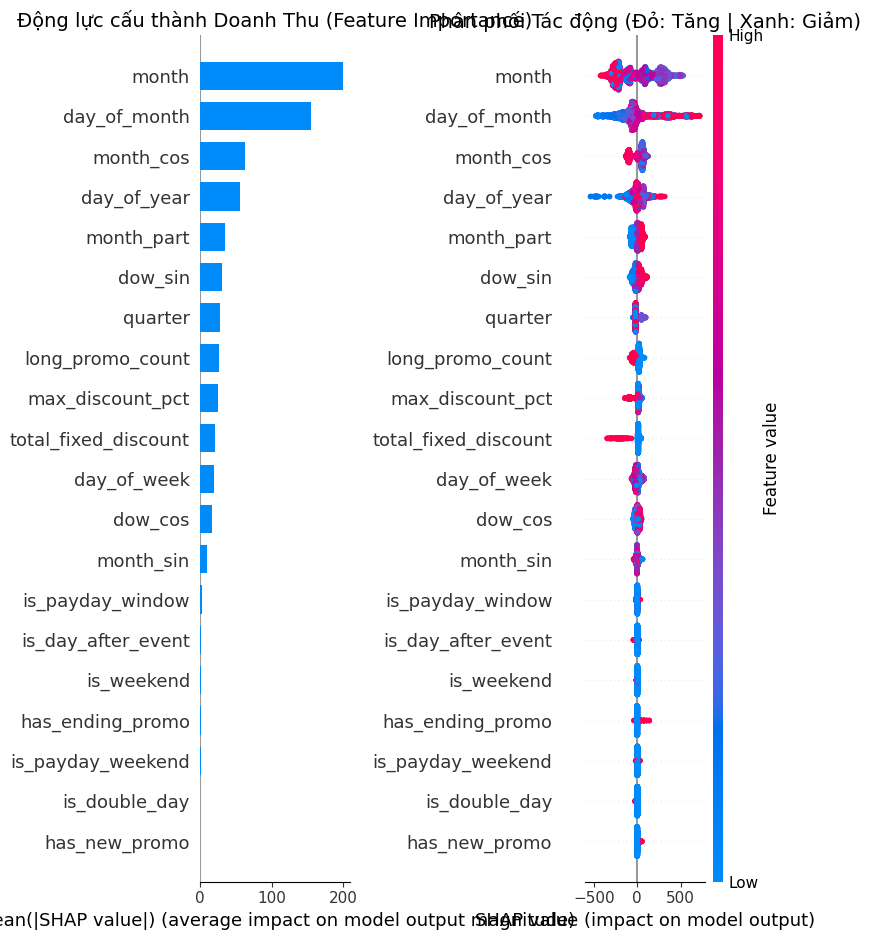

In [19]:
import warnings
warnings.filterwarnings('ignore')

print("📊 Xuất biểu đồ SHAP Values...")
n_samples = min(5000, len(X_train))
X_sample = X_train.sample(n=n_samples, random_state=42)

explainer = shap.TreeExplainer(lgb_model_for_shap)
shap_values = explainer.shap_values(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plt.subplot(1, 2, 1)
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Động lực cấu thành Doanh Thu (Feature Importance)", fontsize=14)

plt.subplot(1, 2, 2)
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("Phân phối Tác động (Đỏ: Tăng | Xanh: Giảm)", fontsize=14)

plt.tight_layout()
plt.show()

# PHẦN 4: HẬU XỬ LÝ (POST-PROCESSING) VÀ QUẢN TRỊ RỦI RO
Khâu cuối cùng là khôi phục kết quả và áp dụng nguyên tắc Kế toán rủi ro:
*   Áp dụng hệ số `0.995` để bóp nhẹ dự báo Doanh thu, chống hiện tượng **Overpredict** (Dự đoán ảo tưởng quá khả năng hấp thụ).
*   Biên độ Giá vốn (COGS) được trộn 80% từ AI và 20% từ biên lợi nhuận vĩ mô lịch sử. Chặn tuyệt đối giới hạn: Giá vốn không được phép vượt qua 95% Doanh thu để tránh dự báo lỗ gộp vô lý.

In [20]:
print("🔮 Đang Hậu xử lý và Xuất file submission...")

final_rev = np.square(np.clip(np.mean(pred_sqrt_rev_list, axis=0), 0, None))
raw_final_cogs = np.square(np.clip(np.mean(pred_sqrt_cogs_list, axis=0), 0, None))

# Bóp nhẹ 0.5% chống Overpredict
final_rev = final_rev * 0.995

# Làm mịn COGS và Chặn giá vốn tối đa 95% Doanh thu
smoothed_cogs = (raw_final_cogs * 0.80) + ((final_rev * global_cogs_ratio) * 0.20)
final_cogs = np.minimum(smoothed_cogs, final_rev * 0.95)

# Xuất file nộp
df_final = dfs['sample_submission'].copy()
df_final['Revenue'] = final_rev
df_final['COGS'] = final_cogs

file_name = 'submission.csv'
df_final.to_csv(file_name, index=False)
print(f"🎉 Hoàn tất! File đã được lưu tại: /content/{file_name}")

🔮 Đang Hậu xử lý và Xuất file submission...
🎉 Hoàn tất! File đã được lưu tại: /content/submission.csv
